# Audio Preprocessing Exploration
**Goal:** Load a raw audio file from the dataset, visualize its waveform, and test our `preprocess_audio` pipeline to ensure silence is trimmed, volume is normalized to 1.0, and the audio is split into consistent 3-second overlapping chunks.

In [ ]:
import os
import sys
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import IPython.display as ipd

# Add the root directory to sys.path so we can import from the 'src' folder
sys.path.append(os.path.abspath(os.path.join('..', '..')))

# Import our custom pipeline
from src.preprocessing.preprocess import preprocess_audio

# Set plotting style
plt.style.use('ggplot')

Raw Sample Rate: 48000 Hz
Raw Duration: 11.00 seconds
Raw Max Amplitude: 0.1554


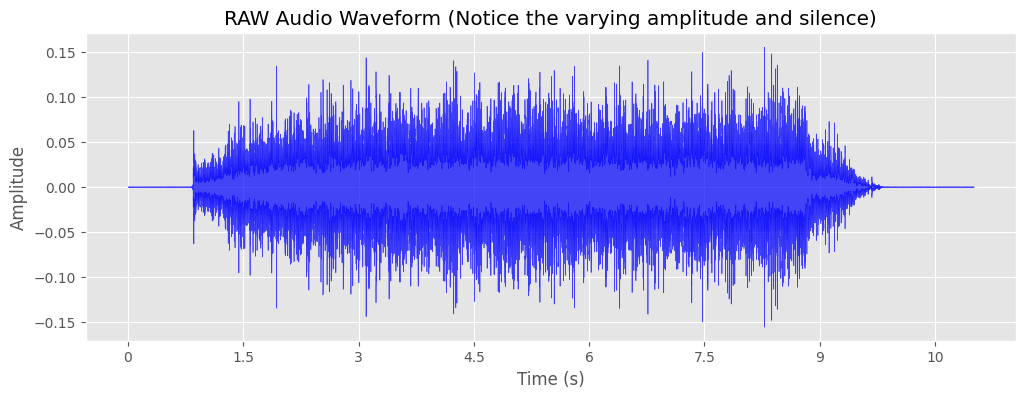

In [5]:
sample_file = "../../data/raw/test.wav"

# Load RAW audio (native sample rate, no processing)
y_raw, sr_raw = librosa.load(sample_file, sr=None)

print(f"Raw Sample Rate: {sr_raw} Hz")
print(f"Raw Duration: {librosa.get_duration(y=y_raw, sr=sr_raw):.2f} seconds")
print(f"Raw Max Amplitude: {np.max(np.abs(y_raw)):.4f}")

# Plot the raw waveform
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y_raw, sr=sr_raw, alpha=0.7, color='blue')
plt.title("RAW Audio Waveform (Notice the varying amplitude and silence)")
plt.ylabel("Amplitude")
plt.xlabel("Time (s)")
plt.show()


In [ ]:
# Pass the file through our pipeline
target_sr = 16000
chunk_duration = 3.0

print("Running preprocess_audio()...")
chunks = preprocess_audio(
    file_path=sample_file, 
    target_sr=target_sr, 
    chunk_duration=chunk_duration, 
    step_duration=1.5
)

print(f"Pipeline Output Shape: {chunks.shape}")
print(f"Generated {chunks.shape[0]} chunks.")
print(f"Each chunk has {chunks.shape[1]} samples (which is exactly {chunks.shape[1]/target_sr} seconds).")


Running preprocess_audio()...
Pipeline Output Shape: (5, 48000)
Generated 5 chunks.
Each chunk has 48000 samples (which is exactly 3.0 seconds).


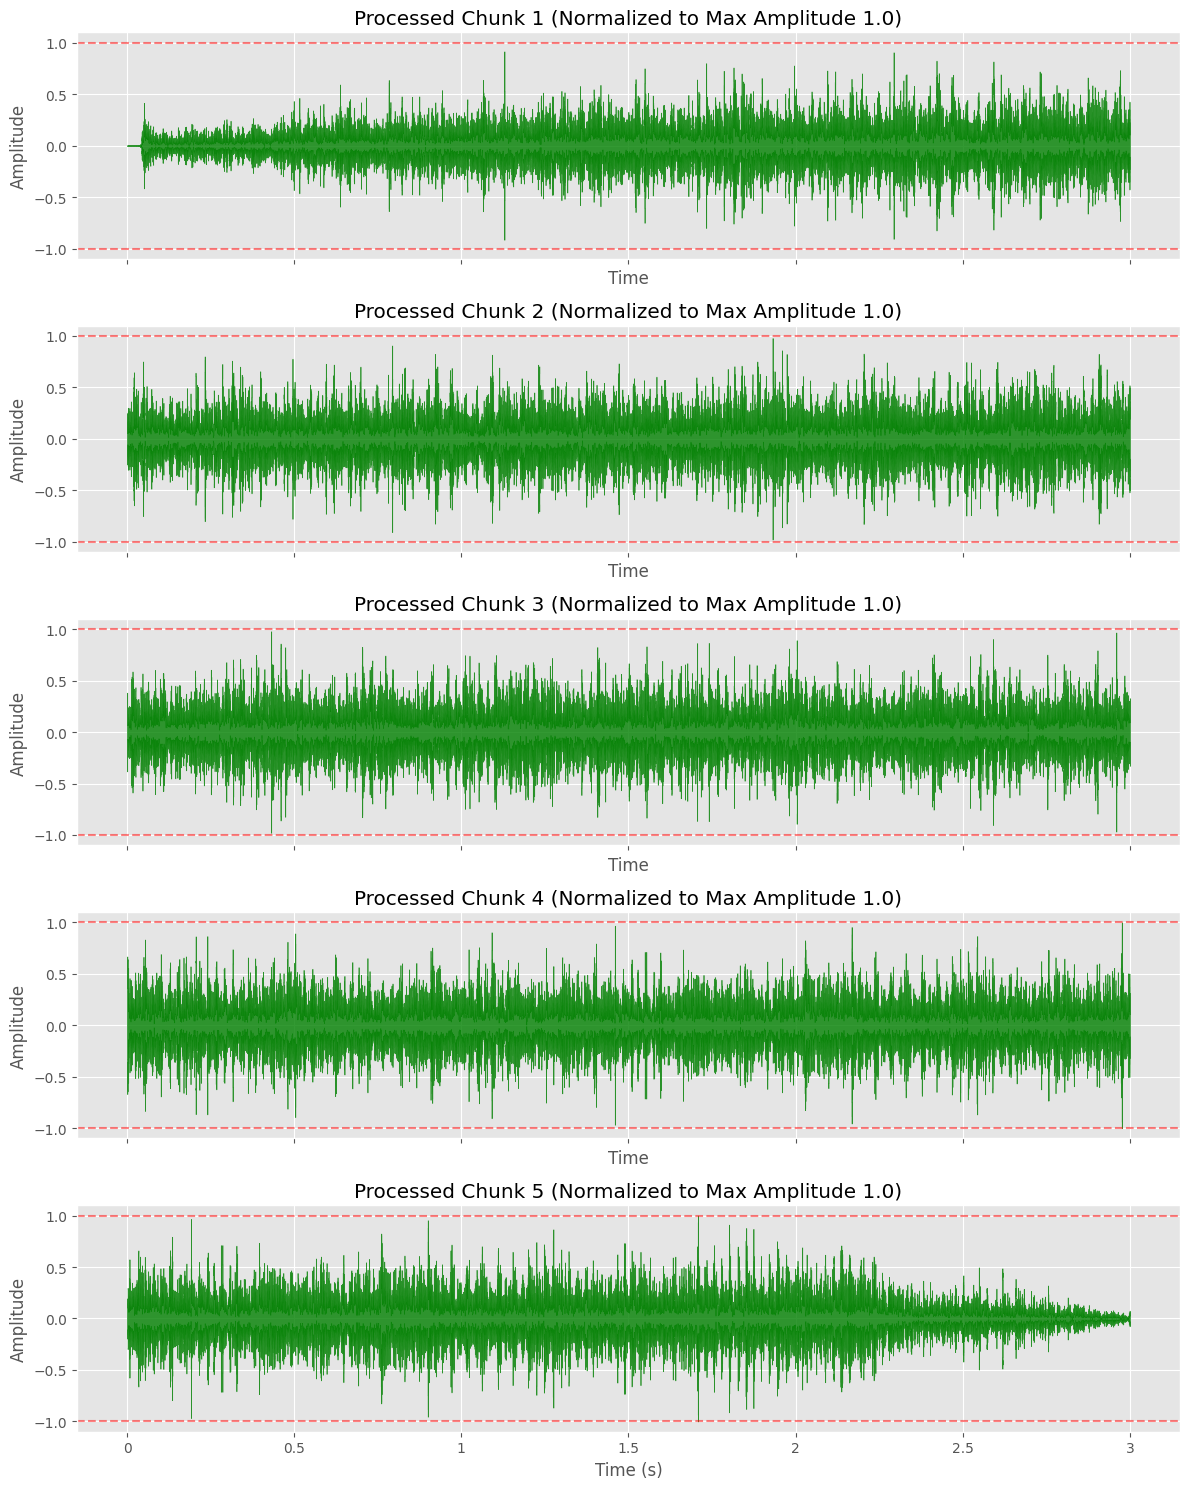

In [7]:
# Plot all generated chunks to prove windowing and normalization worked
num_chunks = chunks.shape[0]

fig, axes = plt.subplots(num_chunks, 1, figsize=(12, 3 * num_chunks), sharex=True, sharey=True)

# Handle the edge case where there is only 1 chunk
if num_chunks == 1:
    axes = [axes]

for i, chunk in enumerate(chunks):
    librosa.display.waveshow(chunk, sr=target_sr, ax=axes[i], alpha=0.8, color='green')
    axes[i].set_title(f"Processed Chunk {i + 1} (Normalized to Max Amplitude 1.0)")
    axes[i].set_ylabel("Amplitude")
    
    # Check max amplitude to prove normalization
    max_amp = np.max(np.abs(chunk))
    axes[i].axhline(y=1.0, color='r', linestyle='--', alpha=0.5)
    axes[i].axhline(y=-1.0, color='r', linestyle='--', alpha=0.5)

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()